# Classifier hyperparameter and PTM comparison

Loads four fixed combined JSON summaries (one per PTM). Uses **NumPy** and **Matplotlib** only (no pandas). Each run is a plain `dict`; numeric stacks use `numpy` arrays where useful.

Edit `JSON_FILES` if your machine uses a different base path than `/home/hc3725/ptm-mamba`.

In [ ]:
from __future__ import annotations

import json

import matplotlib.pyplot as plt
import numpy as np

JSON_FILES = [
    "/home/hc3725/ptm-mamba/classifier_runs/acet_k/acet_k_cnn_gru_bilstm_combined.json",
    "/home/hc3725/ptm-mamba/classifier_runs/met_r/met_r_cnn_gru_bilstm_combined.json",
    "/home/hc3725/ptm-mamba/classifier_runs/phos_y/phos_y_cnn_gru_bilstm_combined.json",
    "/home/hc3725/ptm-mamba/classifier_runs/sumo_k/sumo_k_cnn_gru_bilstm_combined.json",
]

PTMS = ["acet_k", "met_r", "phos_y", "sumo_k"]
ARCHS = ["cnn_bilstm", "cnn_gru"]

plt.rcParams["figure.dpi"] = 120

In [ ]:
def load_json(path: str) -> dict:
    with open(path, "r", encoding="utf-8") as f:
        return json.load(f)


def flatten_runs(data: dict, source_path: str) -> list[dict]:
    rows: list[dict] = []
    ptm = data.get("ptm_type")
    for model_arch, block in (data.get("model_types") or {}).items():
        if not isinstance(block, dict):
            continue
        for run in block.get("runs") or []:
            row: dict = {
                "source_json": source_path,
                "ptm_type": ptm,
                "model_arch": model_arch,
                "timestamp": run.get("timestamp"),
                "run_dir": run.get("run_dir"),
            }
            cfg = run.get("config") or {}
            for k, v in cfg.items():
                if k == "class_weights" and isinstance(v, (list, tuple)) and len(v) == 2:
                    row["class_weight_pos"] = float(v[0])
                    row["class_weight_neg"] = float(v[1])
                elif k != "class_weights":
                    row[f"cfg_{k}"] = v
            fm = run.get("final_metrics_val")
            if isinstance(fm, dict):
                for mk, mv in fm.items():
                    row[f"val_{mk}"] = mv
            row["final_epoch"] = run.get("final_epoch")
            row["final_val_mcc"] = run.get("final_val_mcc")
            if "cfg_conv_layers" in row:
                row["conv_layers"] = row["cfg_conv_layers"]
            if "cfg_rnn_layers" in row:
                row["rnn_layers"] = row["cfg_rnn_layers"]
            rows.append(row)
    return rows


all_rows: list[dict] = []
for path in JSON_FILES:
    all_rows.extend(flatten_runs(load_json(path), path))

valid_rows = [r for r in all_rows if r.get("val_mcc") is not None]
print(f"total runs: {len(all_rows)}, with val_mcc: {len(valid_rows)}")

total runs: 71, with val_mcc: 69


## Best validation MCC per PTM and architecture

Maximum `val_mcc` within each `(ptm_type, model_arch)` group.

In [ ]:
def max_mcc_for_group(rows: list[dict], ptm: str, arch: str) -> tuple[float | None, dict | None]:
    best_m = None
    best_r = None
    for r in rows:
        if r.get("ptm_type") != ptm or r.get("model_arch") != arch:
            continue
        m = r.get("val_mcc")
        if m is None:
            continue
        if best_m is None or m > best_m:
            best_m, best_r = float(m), r
    return best_m, best_r


best_matrix = np.full((len(PTMS), len(ARCHS)), np.nan)
for i, ptm in enumerate(PTMS):
    for j, arch in enumerate(ARCHS):
        m, _ = max_mcc_for_group(valid_rows, ptm, arch)
        if m is not None:
            best_matrix[i, j] = m

print("best val_mcc (rows=PTM, cols=arch):", ARCHS)
for i, ptm in enumerate(PTMS):
    print(ptm, np.array2string(best_matrix[i], precision=4, suppress_small=True))

print("\nBest run details:")
for ptm in PTMS:
    for arch in ARCHS:
        m, r = max_mcc_for_group(valid_rows, ptm, arch)
        if r is None:
            continue
        print(
            f"  {ptm} {arch}: mcc={m:.4f} auroc={r.get('val_auroc')} "
            f"conv={r.get('conv_layers')} rnn={r.get('rnn_layers')} ts={r.get('timestamp')}"
        )

best val_mcc (rows=PTM, cols=arch): ['cnn_bilstm', 'cnn_gru']
acet_k [0.4786 0.5019]
met_r [0.4875 0.4859]
phos_y [0.4213 0.4449]
sumo_k [0.4718 0.4579]

Best run details:
  acet_k cnn_bilstm: mcc=0.4786 auroc=0.8126017619190551 conv=1 rnn=2 ts=20260304_121004
  acet_k cnn_gru: mcc=0.5019 auroc=0.8281366735410917 conv=2 rnn=2 ts=20260304_073113
  met_r cnn_bilstm: mcc=0.4875 auroc=0.8331997496892469 conv=1 rnn=1 ts=20260320_154339
  met_r cnn_gru: mcc=0.4859 auroc=0.8305898757289008 conv=1 rnn=1 ts=20260320_112105
  phos_y cnn_bilstm: mcc=0.4213 auroc=0.8107747229656499 conv=1 rnn=3 ts=20260321_060248
  phos_y cnn_gru: mcc=0.4449 auroc=0.8133431686978833 conv=3 rnn=1 ts=20260321_025300
  sumo_k cnn_bilstm: mcc=0.4718 auroc=0.809478661002796 conv=1 rnn=3 ts=20260320_195324
  sumo_k cnn_gru: mcc=0.4579 auroc=0.8000551618274722 conv=1 rnn=1 ts=20260320_112142


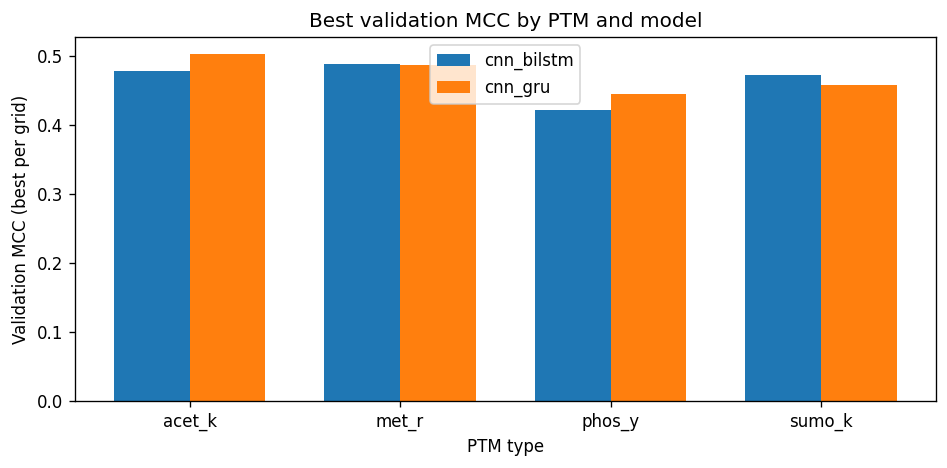

In [ ]:
fig, ax = plt.subplots(figsize=(8, 4))
x = np.arange(len(PTMS))
w = 0.36
for j, arch in enumerate(ARCHS):
    ax.bar(x + (j - 0.5) * w, best_matrix[:, j], w, label=arch)
ax.set_xticks(x)
ax.set_xticklabels(PTMS)
ax.set_ylabel("Validation MCC (best per grid)")
ax.set_xlabel("PTM type")
ax.set_title("Best validation MCC by PTM and model")
ax.legend()
plt.tight_layout()

## Heatmaps: `conv_layers` x `rnn_layers` vs validation MCC

One panel per (PTM, architecture). Missing cells stay empty (NaN).

/tmp/ipykernel_3342751/1682706074.py:56: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


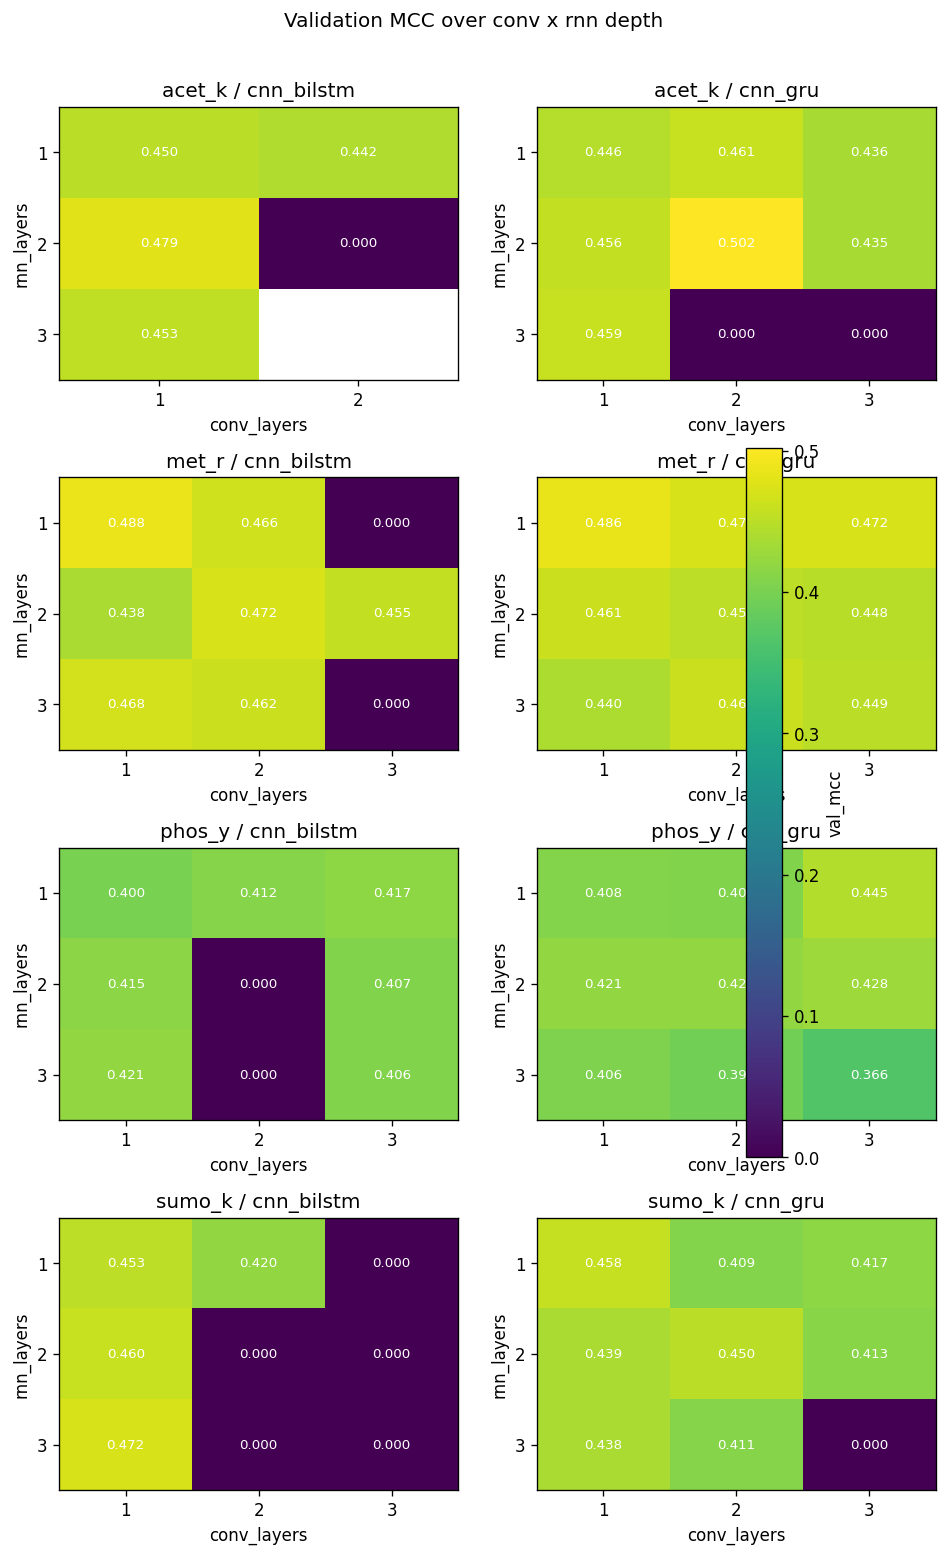

In [ ]:
def heatmap_matrix(rows: list[dict], ptm: str, arch: str) -> tuple[np.ndarray, list, list]:
    sub = [
        r
        for r in rows
        if r.get("ptm_type") == ptm
        and r.get("model_arch") == arch
        and r.get("val_mcc") is not None
        and r.get("conv_layers") is not None
        and r.get("rnn_layers") is not None
    ]
    if not sub:
        return np.array([[]]), [], []
    convs = sorted({int(r["conv_layers"]) for r in sub})
    rnns = sorted({int(r["rnn_layers"]) for r in sub})
    mat = np.full((len(rnns), len(convs)), np.nan)
    buckets = {}
    for r in sub:
        ci = convs.index(int(r["conv_layers"]))
        ri = rnns.index(int(r["rnn_layers"]))
        buckets.setdefault((ri, ci), []).append(float(r["val_mcc"]))
    for (ri, ci), vs in buckets.items():
        mat[ri, ci] = float(np.mean(vs))
    return mat, convs, rnns


all_mcc = np.array([float(r["val_mcc"]) for r in valid_rows], dtype=float)
vmin, vmax = float(all_mcc.min()), float(all_mcc.max())

nrows, ncols = len(PTMS), len(ARCHS)
fig, axes = plt.subplots(nrows, ncols, figsize=(4 * ncols, 3.2 * nrows), squeeze=False)
ims = []
for i, ptm in enumerate(PTMS):
    for j, arch in enumerate(ARCHS):
        ax = axes[i][j]
        mat, convs, rnns = heatmap_matrix(valid_rows, ptm, arch)
        if mat.size == 0 or len(convs) == 0:
            ax.set_visible(False)
            continue
        im = ax.imshow(mat, aspect="auto", cmap="viridis", vmin=vmin, vmax=vmax)
        ims.append(im)
        ax.set_xticks(np.arange(len(convs)))
        ax.set_xticklabels(convs)
        ax.set_yticks(np.arange(len(rnns)))
        ax.set_yticklabels(rnns)
        ax.set_xlabel("conv_layers")
        ax.set_ylabel("rnn_layers")
        ax.set_title(f"{ptm} / {arch}")
        for ri in range(mat.shape[0]):
            for ci in range(mat.shape[1]):
                val = mat[ri, ci]
                if not np.isnan(val):
                    ax.text(ci, ri, f"{val:.3f}", ha="center", va="center", color="w", fontsize=8)
if ims:
    fig.colorbar(ims[0], ax=axes.ravel().tolist(), shrink=0.6, label="val_mcc")
plt.suptitle("Validation MCC over conv x rnn depth", y=1.01)
plt.tight_layout()

## Scatter: AUROC vs MCC

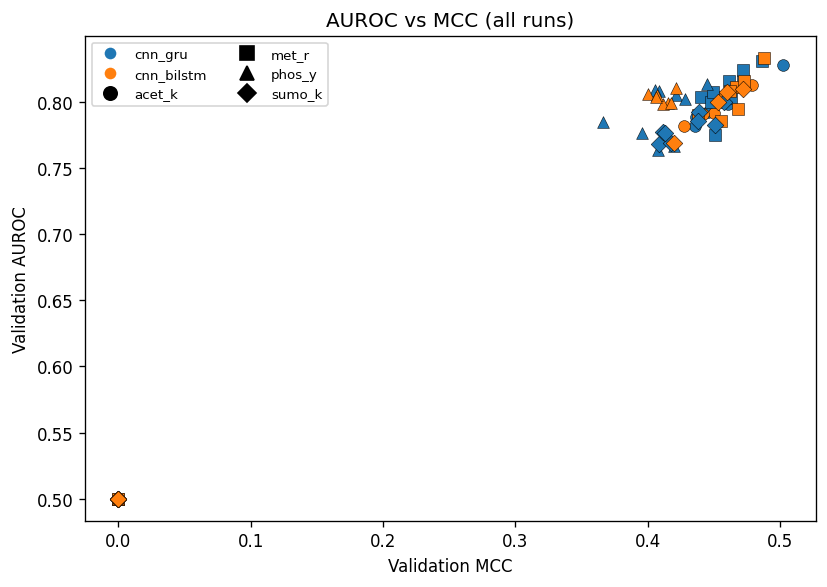

In [ ]:
arch_colors = {"cnn_gru": "C0", "cnn_bilstm": "C1"}
ptm_markers = {"acet_k": "o", "met_r": "s", "phos_y": "^", "sumo_k": "D"}

has_auroc = any(r.get("val_auroc") is not None for r in valid_rows)
if not has_auroc:
    print("No val_auroc; skip scatter.")
else:
    fig, ax = plt.subplots(figsize=(7, 5))
    for r in valid_rows:
        if r.get("val_auroc") is None:
            continue
        a, p = r["model_arch"], r["ptm_type"]
        ax.scatter(
            float(r["val_mcc"]),
            float(r["val_auroc"]),
            c=arch_colors.get(a, "k"),
            marker=ptm_markers.get(p, "o"),
            edgecolors="k",
            linewidths=0.3,
            s=50,
        )
    from matplotlib.lines import Line2D

    leg_arch = [Line2D([0], [0], marker="o", color="w", markerfacecolor=arch_colors[k], label=k, markersize=8) for k in arch_colors]
    leg_ptm = [Line2D([0], [0], marker=ptm_markers[k], color="k", linestyle="None", label=k, markersize=8) for k in PTMS]
    ax.legend(handles=leg_arch + leg_ptm, ncol=2, fontsize=8)
    ax.set_xlabel("Validation MCC")
    ax.set_ylabel("Validation AUROC")
    ax.set_title("AUROC vs MCC (all runs)")
    plt.tight_layout()

## Boxplots: validation MCC by PTM (two architectures per panel)

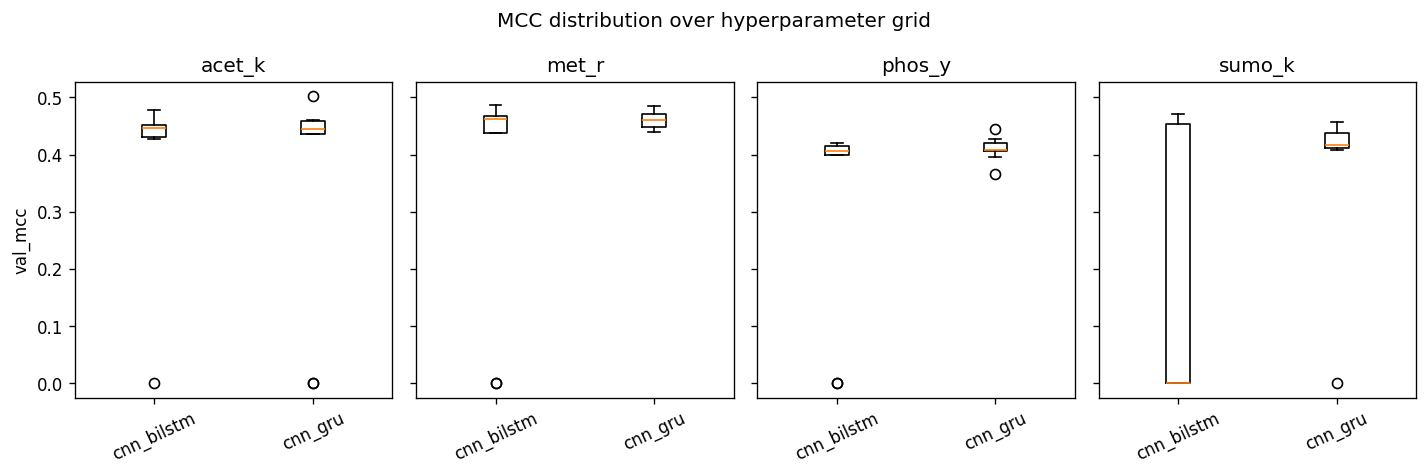

In [ ]:
fig, axes = plt.subplots(1, len(PTMS), figsize=(3 * len(PTMS), 4), sharey=True)
for ax, ptm in zip(axes, PTMS):
    data = []
    for arch in ARCHS:
        vals = [float(r["val_mcc"]) for r in valid_rows if r["ptm_type"] == ptm and r["model_arch"] == arch]
        data.append(vals if vals else [np.nan])
    ax.boxplot(data, tick_labels=ARCHS)
    ax.set_title(ptm)
    ax.tick_params(axis="x", rotation=25)
axes[0].set_ylabel("val_mcc")
plt.suptitle("MCC distribution over hyperparameter grid")
plt.tight_layout()

## Incomplete runs (no `val_mcc`)

In [ ]:
bad = [r for r in all_rows if r.get("val_mcc") is None]
print(f"count: {len(bad)}")
for r in bad:
    print(r.get("ptm_type"), r.get("model_arch"), r.get("timestamp"), r.get("run_dir"))

count: 2
acet_k cnn_gru 20260303_203631 classifier_runs/acet_k/cnn_gru/20260303_203631
acet_k cnn_bilstm 20260304_152439 classifier_runs/acet_k/cnn_bilstm/20260304_152439
